## 10. 텍스트 분석 실습 - 캐글 Mercari Price Suggestion Challenge
Mercari Price Suggestion Challenge는 일본의 대형 온라인 쇼핑몰인 Mercari사의 제품에 대해 가격을 예측하는 과제입니다. 제공되는 데이터 세트는 제품에 대한 여러 속성 및 제품 설명 등의 텍스트 데이터로 구성됩니다.

제공되는 데이터 세트의 속성
- train_id: 데이터 id
- name: 제품명
- item_condition_id: 카테고리 명
- brand_name: 브랜드 이름
- price: 제품 가격, 예측을 위한 타깃 속성
- shipping: 배송비 무료 여부, 1이면 무료(판매자가 지불), 0이면 유료(구매자 지불)
- item_description: 제품에 대한 설명

이들 중 price가 예측해야 할 타깃 값입니다. 회귀로 피처를 학습한 뒤 price를 예측하는 문제입니다. 이번 Mercari Price Suggestion이 기존 회귀 예제와 다른 점은 item_description과 같은 텍스트 형태의 비정형 데이터와 다른 정형 속성을 같이 적용해 회귀를 수행한다는 점입니다.

### 데이터 전처리
먼저 필요한 라이브러리와 함께 meracri_train.csv 데이터를 DataFrame으로 로딩하고, 데이터를 간략하게 살펴보겠습니다.

In [8]:
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd

mercari_df = pd.read_csv('train.tsv', sep='\t')
print(mercari_df.shape)
mercari_df.head(3)

(1482535, 8)


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...


1482535개의 레코드를 가지고 있는 데이터 세트입니다. 다음으로 피처의 타입과 Null 여부를 확인하겠습니다.

In [9]:
print(mercari_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1482535 entries, 0 to 1482534
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   train_id           1482535 non-null  int64  
 1   name               1482535 non-null  object 
 2   item_condition_id  1482535 non-null  int64  
 3   category_name      1476208 non-null  object 
 4   brand_name         849853 non-null   object 
 5   price              1482535 non-null  float64
 6   shipping           1482535 non-null  int64  
 7   item_description   1482529 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 90.5+ MB
None


brand_name 칼럼의 경우 매우 많은 Null 값을 가지고 있습니다. 전체 1482535건 중에 849853건만 Not Null입니다. brand_name은 가격에 영향을 미치는 중요 요인으로 판단되지만, 많은 데이터가 Null로 돼 있습니다. category_name은 약 6300건의 null 데이터를 가지고 있습니다. item_description의 null 값은 4건으로 미비합니다. 이 Null 데이터는 이후에 적절한 문자열로 치환하겠습니다.

Target 값인 price 칼럼의 데이터 분포도를 살펴보겠습니다. 회귀에서 Target 값의 정규 분포도는 매우 중요합니다. 왜곡돼 있을 경우 보통 로그를 씌워서 변환하면 대부분 정규 분포의 형태르 가지게 됩니다. 먼저 price 칼럼의 데이터 값 분포도를 확인해 보겠습니다.

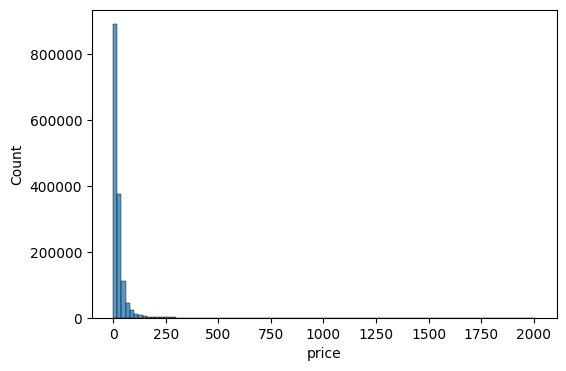

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

y_train_df = mercari_df['price']
plt.figure(figsize=(6,4))
sns.histplot(y_train_df, bins=100)
plt.show()

price 값이 비교적 적은 가격을 가진 데이터 값에 왜곡돼 분포돼 있습니다. Price 칼럼을 로그 값으로 변환한 뒤 분포도를 다시 살펴보겠습니다.

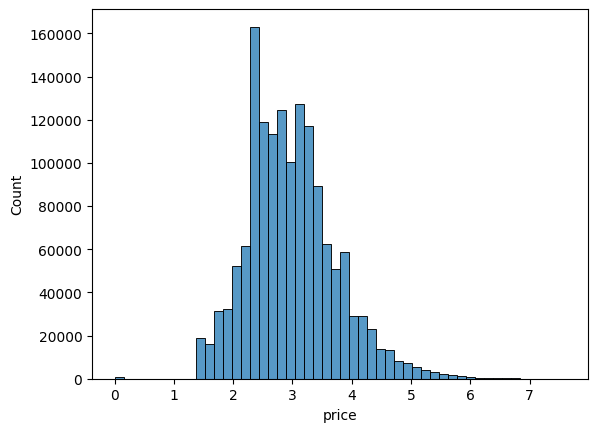

In [12]:
import numpy as np

y_train_df = np.log1p(y_train_df)
sns.histplot(y_train_df, bins=50)
plt.show()

로그 값으로 변환하면 price 값이 비교적 정규 분포에 가까운 데이터를 이루게 됩니다. 데이터 세트의 price 칼럼을 원래 값에서 로그로 변환된 값으로 변경하겠습니다.

In [13]:
mercari_df['price'] = np.log1p(mercari_df['price'])
mercari_df['price'].head(3)

,price
0,2.397895
1,3.970292
2,2.397895


다른 피처의 값도 살펴보겠습니다. shipping과 item_condition_id 값의 유형은 다음과 같습니다.

In [15]:
print('Shipping 값 유형:\n', mercari_df['shipping'].value_counts())
print('item_condition_id 값 유형:\n', mercari_df['item_condition_id'].value_counts())

Shipping 값 유형:
 shipping
0    819435
1    663100
Name: count, dtype: int64
item_condition_id 값 유형:
 item_condition_id
1    640549
3    432161
2    375479
4     31962
5      2384
Name: count, dtype: int64


Shipping 칼럼은 배송비 유무이며, 값이 비교적 균일합니다. Item_condition_id는 판매자가 제공하는 제품 상태로서 각 값이 의미하는 바는 캐글에 기재돼 있지 않아서 알 수 없지만, 1, 2, 3 값이 주를 이루고 있습니다.

item_description 칼럼은 Null 값은 별로 없지만, description에 대한 별도 설명이 없는 경우 'No description yet' 값으로 돼 있습니다. 이러한 값이 얼마나 있는지 알아보겠습니다.

In [16]:
boolean_cond = mercari_df['item_description'] == 'No description yet'
mercari_df[boolean_cond]['item_description'].count()

np.int64(82489)

item_description 'No description yet'으로 돼 있는 로우는 82489건입니다. 'No description yet'의 경우도 Null과 마찬가지로 의미 있는 속성값으로는 사용될 수 없으므로 적절한 값으로 변경해야 합니다.

category_name을 살펴보겠습니다. categoryjname은 '/'로 분리된 카테고리를 하나의 문자열로 나타내고 있습니다. 가령 'Men/Tops/T—shirts'는 대분류 'Men', 중분류 'Tops', 소분류 'T-shirts'로 나눌 수 있습니다. category_name은 텍스트이므로 피처 추출 시 tokenizer를 /로 하여 단어를 분리해 벡터화할 수도 있습니다만, 여기서는 category_name의 /를 기준으로 단어를 토큰화해 각각 별도의 피처로 저장하고 이를 이용해 알고리즘을 학습시키겠습니다.

category_name 칼럼을 '/'를 기준으로 대, 중, 소분류를 효과적으로 분리해 내기 위해 별도의 split_cat() 함수를 생성하고 이를 DataFrame의 apply lambda 식에 적용하겠습니다. category name 칼럼은 Null값을 약 6300여 건을 가지고 있으므로 이에 유의하면서 분리를 해내야 합니다. split_cat() 함수를 간략히 살펴보면, 먼저 category_name 이 Null 이 아닌 경우에 split('/') 를 이용해 대, 중, 소 분류를 분리합니다. 파이썬은 문자열에 split(tokenizer문자) 함수를 호출하면 tokenizer 문자에 따라 문자열을 분리해 리스트로 반환합니다. 만일 category name이 Null일 경우에는 split() 함수가 Error를 발생하므로 이 Error를 except catch하여 대, 중, 소 분류 모두 ‘Other Null’ 값을 부여합니다.

대, 중, 소 칼럼은 mercari_df에서 cat_dae, cat_jung, cat_so로 부여하겠습니다. 한 가지 고민해야 할 점은 판다스의 apply lambda로 반환되는 데이터 세트가 리스트를 요소로 가지고 있는데, 이를 다시 cat_dae, cat_jung, cat_so의 DataFrame 칼럼.0-류. 분리해야 하는 것입니다. 이 부분은 다음 코드에서처럼 zip과 *를 apply lambda 식에 적용하면 여러 개의 칼럼으로 간단하게 분리할수 있습니다.

In [17]:
# apply lambda에서 호출되는 대, 중, 소 분할 함수 생성, 대, 중, 소 값을 리스트로 반환
def split_cat(category_name):
  try:
    return category_name.split('/')
  except:
    return ['Other Null', 'Other Null', 'Other Null']

# 위의 split_cat()을 apply lambda에서 호출해 대, 중, 소 칼럼을 mercari_df에 생성.
mercari_df['cat_dae'], mercari_df['cat_jung'], mercari_df['cat_so'] = \
                      zip(*mercari_df['category_name'].apply(lambda x : split_cat(x)))

# 대분류만 값의 유형과 건수를 살펴보고, 중분류, 소분류는 값의 유형이 많으므로 분류 개수만 추출
print('대분류 유형:\n', mercari_df['cat_dae'].value_counts())
print('중분류 개수: ', mercari_df['cat_jung'].nunique())
print('소분류 개수: ', mercari_df['cat_so'].nunique())

대분류 유형:
 cat_dae
Women                     664385
Beauty                    207828
Kids                      171689
Electronics               122690
Men                        93680
Home                       67871
Vintage & Collectibles     46530
Other                      45351
Handmade                   30842
Sports & Outdoors          25342
Other Null                  6327
Name: count, dtype: int64
중분류 개수:  114
소분류 개수:  871


대분류의 경우 Women, Beauty, Kids 등의 분류가 매우 많습니다. 중분류 유형은 114개, 소분류는 817개로 구성돼 있습니다.

마지막으로 brand_name, category name, item_description 칼럼의 Null 값은 일괄적으로 'Other Null'로 동일하게 변경하겠습니다. brand_name은 price 값 결정에 영향을 많이 줄 것으로 판단되지만, Null 값이 매우 많습니다. 아쉽게도 이 Null 값을 다른 값으로 변경하는 것은 적절하지 않을 것으로 판단되므로 일괄적으로 'Other_Null'로 변경하겠습니다. fillna()를 적용한 뒤에 각 칼럼별로 Null값이 없는지 다음과 같이 mercari_df.isnull( ).sum()을 호출해 확인하면 모든 칼럼에서 Null 건수가 0 임을 알수 있습니다.

In [18]:
mercari_df['brand_name'] = mercari_df['brand_name'].fillna(value='Other_Null')
mercari_df['category_name'] = mercari_df['category_name'].fillna(value='Other_Null')
mercari_df['item_description'] = mercari_df['item_description'].fillna(value='No description yet')

# 각 칼럼별로 Null 값 건수 확인. 모두 0이 나와야 합니다.
mercari_df.isnull().sum()

,0
train_id,0
name,0
item_condition_id,0
category_name,0
brand_name,0
price,0
shipping,0
item_description,0
cat_dae,0
cat_jung,0


데이터 클린징 작업은 이 정도 수준까지만 진행하겠습니다. 다음으로는 칼럼을 숫자형 코드 값으로 인코딩하고, 텍스트형 칼럼에 대해서는 피처 벡터화 변환을 적용하겠습니다.

### 피처 인코딩과 피처 벡터화
Mercari Price Suggestion에 이용되는 데이터 세트는 문자열 칼럼이 많습니다. 이 문자열 칼럼 중 레이블 또는 원-핫 인코딩을 수행하거나 피처 벡터화로 변환할 칼럼을 선별해 보겠습니다. 먼저 이 피처를 어떤 방식으로 변환할지 검토한 후에 추후에 일괄적으로 전체 속성의 변환 작업을 적용하겠습니다. Mercari Price Suggestion에서 예측 모델은 price 값, 즉 상품 가격을 예측해야 하므로 회귀 모델을 기반으로 합니다. 선형 회귀 모델과 회귀 트리 모델을 모두 적용할 예정이며, 특히 선형 회귀의 경우 원-핫 인코딩 적용이 훨씬 선호되므로 인코딩할 피처는 모두 원-핫 인코딩을 적용하겠습니다. 피처 벡터화의 경우는 비교적 짧은 텍스트의 경우는 Count 기반의 벡터화를, 긴 텍스트는 TD-IDF 기반의 벡터화를 적용하겠습니다.

첫 번째로 검토할 칼럼은 brand_name입니다. brand_name 칼럼은 상품의 브랜드명입니다. 상품 브랜드명이 어떤 유형으로 돼 있는지 유형 건수와 대표적인 브랜드명을 5개 정도만 살펴보겠습니다

In [19]:
print('brand name의 유형 건수 :', mercari_df['brand_name'].nunique())
print('brand name smaple 5건 : \n', mercari_df['brand_name'].value_counts()[:5])

brand name의 유형 건수 : 4810
brand name smaple 5건 : 
 brand_name
Other_Null           632682
PINK                  54088
Nike                  54043
Victoria's Secret     48036
LuLaRoe               31024
Name: count, dtype: int64


brand_name의 경우 대부분 명료한 문자열로 돼 있습니다. 별도의 피처 벡터화 형태로 만들 필요 없이 인코딩 변환을 적용하면 됩니다. brand_name의 종류가 4810건으로 원-핫 인코딩으로 변환하기에 다소 많아 보이나 본 예제의 ML 모델 구축상 큰 문제는 없습니다. brand_name은 원-핫 인코딩 변환하겠습니다. 다음으로 상품명을 의미하는 name 속성이 어떤 유형으로 돼 있는지 유형 건수와 상품명을 7개만 출력해 보겠습니다.

In [20]:
print('name의 종류 개수:', mercari_df['name'].nunique())
print('name sample 7건: \n', mercari_df['name'][:7])

name의 종류 개수: 1225273
name sample 7건: 
 0    MLB Cincinnati Reds T Shirt Size XL
1       Razer BlackWidow Chroma Keyboard
2                         AVA-VIV Blouse
3                  Leather Horse Statues
4                   24K GOLD plated rose
5       Bundled items requested for Ruie
6     Acacia pacific tides santorini top
Name: name, dtype: object


상품명은 name 속성의 경우 종류가 매우 많습니다. 무려 1,225,273가지입니다. 전체 데이터가 1,482,535개이므로 개별적으로 거의 고유한 상품명을 가지고 있습니다. Name 속성은 유형이 매우 많고, 적은 단어 위주의 텍스트 형태로 돼 있으므로 Count 기반으로 피처 벡터화 변환을 적용하겠습니다.

category_name 칼럼은 이전에 전처리를 통해서 해당 칼럼은 대, 중, 소 분류 세 개의 칼럼인 cat_dae, cat_jung, cat_so 칼럼으로 분리됐습니다. cat_dae, cat_jung, cat_so 칼럼도 원-핫 인코딩을 적용하겠습니다.

shipping 칼럼은 배송비 무료 여부로서 0과 1, 두 가지 유형의 값을 가지고 있으며 item_condition_id는 상품 상태로서 1, 2, 3, 4, 5의 다섯 가지 유형의 값을 가지고 있습니다. 이 두 칼럼 모두 원-핫 인코딩을 적용하겠습니다.

다음으로 item_description입니다. Item_description은 상품에 대한 간단 설명으로 데이터 세트에서 가장 긴 텍스트를 가지고 있습니다. 해당 칼럼의 평균 문자열 크기와 2개 정도의 텍스트만 추출해 보겠습니다.

In [21]:
pd.set_option('max_colwidth', 200)

# item_description의 평균 문자열 크기
print('item_description 평균 문자열 크기:', mercari_df['item_description'].str.len().mean())

mercari_df['item_description'][:2]

item_description 평균 문자열 크기: 145.711429409761


,item_description
0,No description yet
1,This keyboard is in great condition and works like it came out of the box. All of the ports are tested and work perfectly. The lights are customizable via the Razer Synapse app on your PC.


평균 문자열이 145자로 비교적 크므로 해당 칼럼은 TF-IDF로 변환하겠습니다.

이제 주요 칼럼을 인코딩 및 피처 벡터화 변환해 보겠습니다. 먼저 name과 item_description 칼럼을 피처 벡터화합니다. name 칼럼의 경우는 CountVbctorizer로, item_description 칼럼은 TfidfVectorizer로 변환하겠습니다. CountViectorizer는 기본 파라미터로, TfidfWctorizer는 max features = 50000으로 제한하고 n_gram은 triple gram인 ngram_range=(l,3), stop_words는 english로 설정합니다.

In [23]:
# name 속성에 대한 피처 벡터화 변환
cnt_vec = CountVectorizer()
X_name = cnt_vec.fit_transform(mercari_df['name'])

# item_description 속성에 대한 피처 벡터화 변환
tfidf_descp = TfidfVectorizer(max_features=50000, ngram_range=(1,3), stop_words='english')
X_descp = tfidf_descp.fit_transform(mercari_df['item_description'])

print('name vertorization shape:', X_name.shape)
print('item_description vectorization shape:', X_descp.shape)

name vertorization shape: (1482535, 105757)
item_description vectorization shape: (1482535, 50000)


CountVectorizer, TfidfVectorizer가 fit_transform()을 통해 반환하는 데이터는 희소 행렬 형태입니다. 희소 행렬 객체 변수인 X_name과 X_descp를 새로 결합해 새로운 데이터 세트로 구성해야 하고, 앞으로 인코딩될 cat_dae, cat_jung, cat_so, brand_name, shipping, item_condition_id도 모두 X_name, X_descp와 결합돼 ML 모델을 실행하는 기반 데이터 세트로 재구성돼야 합니다.

이를 위해서 이 인코딩 대상 칼럼도 밀집 행렬 행태가 아닌 희소 행렬 형태로 인코딩을 적용한 뒤, 함께 결합하도록 하겠습니다. 사이킷런은 원-핫 인코딩을 위해 OneHotEncoder와 LabelBinarizer 클래스를 제공합니다. 이 중 LabelBinarizer 클래스는 희소 행렬 형태의 원-핫 인코딩 변환을 지원합니다. 생성 시 sparse_out=True로 파라미터를 설정해주기만 하면 됩니다. 모든 인코딩 대상 칼럼은 LabelBinarizer를 이용해 희소 행렬 형태의 원-핫 인코딩으로 변환하겠습니다. 개별 칼럼으로 만들어진 희소 행렬은 사이파이 패키지 sparse 모듈의 hstack() 함수를 이용해 결합하겠습니다. hstack() 함수는 희소 행렬을 손쉽게 칼럼 레벨로 결합할 수 있게 해줍니다.

먼저 인코딩 대상 칼럼을 모두 LabelBinarizer로 원-핫 인코딩 변환하겠습니다.

In [28]:
from sklearn.preprocessing import LabelBinarizer

# brand_name, item_condition_id, shipping 각 피처들을 희소 행렬 원-핫 인코딩 변환
lb_brand_name = LabelBinarizer(sparse_output=True)
X_brand = lb_brand_name.fit_transform(mercari_df['brand_name'])
lb_item_cond_id = LabelBinarizer(sparse_output=True)
X_item_cond_id = lb_item_cond_id.fit_transform(mercari_df['item_condition_id'])
lb_shipping = LabelBinarizer(sparse_output=True)
X_shipping = lb_shipping.fit_transform(mercari_df['shipping'])

# cat_dae, cat_jung, cat_so 각 피처들을 희소 행렬 원-핫 인코딩 변환
lb_cat_dae = LabelBinarizer(sparse_output=True)
X_cat_dae = lb_cat_dae.fit_transform(mercari_df['cat_dae'])
lb_cat_jung = LabelBinarizer(sparse_output=True)
X_cat_jung = lb_cat_jung.fit_transform(mercari_df['cat_jung'])
lb_cat_so = LabelBinarizer(sparse_output=True)
X_cat_so = lb_cat_so.fit_transform(mercari_df['cat_so'])

제대로 변환됐는지 생성된 인코딩 데이터 세트의 타입과 shape을 살펴보겠습니다.

In [29]:
print(type(X_brand), type(X_item_cond_id), type(X_shipping))
print('X_brand shape:{0}, X_item_cond_id shape:{1}'.format(X_brand.shape, X_item_cond_id.shape))
print('X_shipping shape:{0}, X_cat_dae shape:{1}'.format(X_shipping.shape, X_cat_dae.shape))
print('X_cat_jung shape:{0}, X_cat_so shape:{1}'.format(X_cat_jung.shape, X_cat_so.shape))

<class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'>
X_brand shape:(1482535, 4810), X_item_cond_id shape:(1482535, 5)
X_shipping shape:(1482535, 1), X_cat_dae shape:(1482535, 11)
X_cat_jung shape:(1482535, 114), X_cat_so shape:(1482535, 871)


인코딩 변환된 데이터 세트가 CSR 형태로 변환된 csr_matrix 타입입니다. 그리고 brand_name 칼럼 경우 값의 유형이 4810개이므로 이를 원-핫 인코딩으로 변환한 X_brand_shape의 경우 4810개의 인코딩 칼럼을 가지게 되었습니다. X_cat_so의 경우도 마찬가지로 8기개의 인코딩 칼럼을 가집니다. 인코딩 칼럼이 매우 많이 생겼지만, 피처 벡터화로 텍스트 형태의 문자열이 가지는 벡터 형태의 매우 많은 칼럼과 함께 결합되므로 크게 문제 될 것은 없습니다.

이번에는 앞에서 피처 벡터화 변환한 데이터 세트와 희소 인코딩 변환된 데이터 세트를 hstack()을 이용해 모두 결합해 보겠습니다. 결합된 데이터는 Mercari Price Suggestion을 위한 기반 데이터 세트로 사용되는데, 여기서는 결합한 데이터의 타입과 크기만 확인하고 메모리에서 삭제하도록 하겠습니다. 만들어진 결합 데이터가 비교적 많은 메모리를 잡아먹기 때문에 개인용 PC에서 메모리 오류가 발생할 수 있기에 del '객체 변수명'과 gc.collect()로 결합 데이터를 메모리에서 삭제합니다.

In [30]:
from scipy.sparse import hstack
import gc

sparse_matrix_list = (X_name, X_descp, X_brand, X_item_cond_id, \
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)

# hstack 함수를 이용해 인코딩과 벡터화를 수행한 데이터 세트를 모두 결합.
X_features_sparse = hstack(sparse_matrix_list).tocsr()
print(type(X_features_sparse), X_features_sparse.shape)

# 데이터 세트가 메모리를 많이 차지하므로 사용 목적이 끝났으면 바로 메모리에서 삭제.
del X_features_sparse
gc.collect()

<class 'scipy.sparse._csr.csr_matrix'> (1482535, 161569)


485

hstack()으로 결합한 데이터 세트는 csr_matrix 타입이며, 총 161569개의 피처를 가지게 됐습니다. 이제 이렇게 만들어진 데이터 세트에 회귀를 적용해 price 값을 예측할 수 있도록 모델을 만들 차례입니다.

### 릿지 회귀 모델 구축 및 평가
여러 알고리즘 모델과 희소 행렬을 변환하고 예측 성능을 비교하면서 테스트를 수행할 것이므로 수행에 필요한 로직을 함수화하겠습니다. 먼저 모델을 평가하는 평가(Evaluation) 로직을 함수화하겠습니다. 적용할 평가 지표는 캐글에서 제시한 RMSLE(Root Mean Square Logarithmic Error) 방식으로 하겠습니다. RMSLE는 RMSE와 유사하나 오류 값에 로그를 취해 RMSE를 구하는 방식입니다. 낮은 가격(price)보다 높은 가격에서 오류가 발생할 경우 오류 값이 더 커지는 것을 억제하기 위해서 이 방식을 도입했습니다.

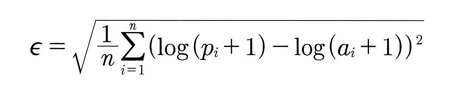

별도의 RMSLE를 구하는 함수를 rmsle(y, y_pred)로 생성하겠습니다. 한 가지 주의해야 할 사항은 원본 데이터의 price 칼럼의 값은 왜곡된 데이터 분포를 가지고 있기 때문에 이를 정규 분포 형태로 유도하기 위해 로그 값을 취해 변환했습니다. 즉, 학습할 모델이 사용할 price 값은 로그 값으로 변환된 price 값이므로 예측도 당연히 로그로 변환한 데이터 값 수준의 price 값을 예측할 것입니다. 따라서 학습 모델을 이용한 예측된 price 값은 다시 로그의 역변환인 지수(Exponential) 변환을 수행해 원복해야 합니다. 이렇게 원복된 데이터를 기반으로 RMSLE를 적용할 수 있도록 evaluate_org_price(y_test, preds) 함수를 생성하겠습니다.

In [36]:
def rmsle(y, y_pred):
    # underflow, oberflow를 막기 우히ㅐ log가 아닌 log1p로 rmsle 계산
    return np.sqrt(np.mean(np.power(np.log1p(y) - np.log1p(y_pred), 2)))

def evaluate_org_price(y_test, preds):

    # 원본 데이터는 log1p로 변환되었으므로 exmpm1로 원복 필요.
    preds_exmpm = np.expm1(preds)
    y_test_exmpm = np.expm1(y_test)

    # rmsle로 RMSLE 값 추출
    rmsle_result = rmsle(y_test_exmpm, preds_exmpm)
    return rmsle_result

학습용 데이터를 생성하고, 모델을 학습/예측하는 로직을 별도의 함수로 만들겠습니다. 다음의 model_train_predict() 함수는 model 인자로 사이킷런의 회귀 estimator 객체를, matrix_list 인자로 최종 데이터 세트로 결합할 희소 행렬 리스트를 가집니다. 평가 데이터 세트는 train_test_split()을 이용해 전체 데이터의 20%로 하겠습니다.

In [32]:
import gc
from scipy.sparse import hstack
def model_train_predict(model, matrix_list):
  # scipy.sparse 모듈의 hstack을 이용해 희소 행렬 결합
  X= hstack(matrix_list).tocsr()
  X_train, X_test, y_train, y_test=train_test_split(X, mercari_df['price'],
                                                    test_size=0.2, random_state=156)

  # 모델 학습 및 예측
  model.fit(X_train, y_train)
  preds = model.predict(X_test)

  del X, X_train, X_test, y_train
  gc.collect()

  return preds, y_test

개별 함수를 만들었으면 이제 이를 이용해 먼저 Ridge를 이용해 Mercari Price의 회귀 예측을 수행하겠습니다. 수행 전에 Merari 상품 가격 예측에 item_description과 같은 텍스트 형태의 속성이 얼마나 영향을 미치는지 알아보겠습니다. Item_description 속성의 피처 벡터화 데이터가 포함되지 않았을 때와 포함됐을 때의 예측 성능을 다음 예제 코드와 같이 비교할 수 있습니다.

In [37]:
linear_model = Ridge(solver = "lsqr", fit_intercept=False)

sparse_matrix_list = (X_name, X_brand, X_item_cond_id, \
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list)
print('Item Description을 제외했을 때 rmsle 값:', evaluate_org_price(y_test, linear_preds))

sparse_matrix_list = (X_descp, X_name, X_brand, X_item_cond_id, \
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list)
print('Item Description을 포함한 rmsle 값:', evaluate_org_price(y_test, linear_preds))

Item Description을 제외했을 때 rmsle 값: 0.4983990938999374
Item Description을 포함한 rmsle 값: 0.46800455948845926


Item Description을 포함했을 때 rmsle 값이 많이 감소했습니다. Item description 영향이 중요함을 알 수 있습니다.

### LightGBM 회귀 모델 구축과 앙상블을 이용한 최종 예측 평가
다음으로는 LightGBM을 이용해 회귀를 수행한 뒤, 위에서 구한 릿지 모델 예측값과 LightGBM 모델 예측값을 간단한 앙상블(Ensemble) 방식으로 섞어서 최종 회귀 예측값을 평가하겠습니다.

먼저 LightGBM으로 회귀를 수행하겠습니다. n_estimators를 200으로 작게 설정하고 예측 성능을 측정해 보겠습니다.

In [38]:
# from lightgbm import LGBMRegressor

# sparse_matrix_list = (X_descp, X_name, X_brand, X_item_cond_id,
#                       X_shipping, X_cat_dae, X_cat_jung, X_cat_so)

# lgbm_model = LGBMRegressor(n_estimators=200, learning_rate=0.5, num_leaves=125, random_state=156)
# lgbm_preds, y_test = model_train_predict(model = lgbm_model, matrix_list=sparse_matrix_list)
# print('LightGBM rmsle 값:', evaluate_org_price(y_test, lgbm_preds))

앞 예제의 Ridge보다 예측 성능이 더 나아졌습니다. 다음으로 이렇게 구한 LightGBM의 예측 결괏값과 위에서 구한 Ridge의 예측 결괏값을 서로 앙상블해 최종 예측 결괏값을 도출하겠습니다. LightGBM 결괏값에 0.45를 곱하고 Ridge 결괏값에 0.55를 곱한 값을 서로 합해 최종 예측 결괏값으로 하겠습니다. 앞에서 구한 Ridge 예측 데이터 세트인 linear_preds에 일괄적으로 0.55를 곱하고, LightGBM 예측 데이터 세트인 lgbm_preds에 일괄적으로 0.45를 곱한 뒤 합한 결과 데이터 세트로 예측 성능 결과를 다시 측정해 보겠습니다.

In [39]:
# preds = lgbm_preds * 0.45 + linear_preds * 0.55
# print('LightGBM과 Ridge를 ensemble한 최종 rmsle 값:', evaluate_org_price(y_test, preds))

간단한 앙상블 방식으로 예측 성능을 더 개선했습니다.

## 11. 정리
이 장에서는 텍스트 분석을 위한 기반 프로세스를 상세히 알아보고, 이를 통해 텍스트 분류, 감성 분석, 토픽 모델링, 텍스트 군집화 및 유사도 측정 등을 직접 파이썬 코드를 이용해 구현해 봤습니다. 머신러닝 기반의 텍스트 분석 프로세스는 첫째 텍스트 사전 정제 작업 등의 텍스트 정규화 작업을 수행하고 둘째 이들 단어들을 피처 벡터화로 변환합니다. 셋째, 이렇게 생성된 피처 벡터 데이터 세트에 머신러닝 모델을 학습하고 예측, 평가합니다.

텍스트 정규화 작업은 텍스트 클렌징 및 대소문자 변경, 단어 토큰화, 의미 없는 단어 필터링, 어근 추출 등 피처 벡터화를 진행하기 이전에 수행하는 다양한 사전 작업을 의미합니다. 피처 벡터화는 BOW의 대표 방식인 Count 기반과 TF-IDF 기반 피처 벡터화를 설명했습니다. 일반적으로 문서의 문장이 긴 경우 TF-IDF 기반의 피처 벡터가 더 정확한 결과를 도출하는 데 도움이 됩니다. 이렇게 만들어진 피처 벡터 데이터 세트는 희소 행렬이며, 머신러닝 모델은 이러한 희소 행렬 기반에서 최적화되어야 합니다.

텍스트 분류절에서는 문서들을 피처 벡터화한 후 로지스틱 회귀를 적용해 문서를 지도학습 방식으로 예측 분류해 봤습니다. 감성 분석절에서는 지도학습 기반으로 긍정/부정 이진 분류를 적용한 방식과 SentiWordNet, VADER와 같은 감성 사전 Lexicon을 이용한 방식 두 가지를 살펴봤습니다. 토픽 모델링은 LDA(Latent Dirichlet Allocation)를 이용해 뉴스그룹 내의 많은 문서들이 공통적으로 가지는 토픽들을 추출해 봤습니다. 텍스트 군집화는 K-평균 군집화 기법을 이용해 비슷한 문서들끼리 군집화했고 텍스트 유사도 측정에서는 코사인 유사도를 이용해 문서들끼리 얼마나 비슷한지를 측정해 봤습니다. 파이썬의 대표적인 한글 형태소 분석기인 KoNLPy 패키지를 이용해 네이버에서 제공하는 한글로 된 영화 리뷰에 긍정/부정 이진 분류를 적용해 봤습니다. 마지막으로 Mercari Price Challenge 실습에서는 정형 피처들과 텍스트와 같은 비정형 피처를 결합해 효과적으로 회귀 예측 모델을 구현했습니다.

텍스트 분석과 같은 비정형 데이터의 분석은 머신러닝을 통해 많은 발전을 가져왔습니다. 과거에는 단순히 보관용에 지나지 않았던 이들 비정형 데이터들이 머신러닝 기법의 도입으로 새로운 데이터로서의 가치를 부여받고 있습니다. 특히 기존의 데이터들과 이들 비정형 데이터가 결합된 형태로 제공되는 분석은 기존 분석이 가져다 주지 못한 새로운 인사이트들을 제공할 수 있게 되었습니다.